In [514]:
import numpy as np
from hetero_isas.monodromy_lp import (
    MonodromyLPDecomposer,
    MonodromyLPGate,
    MonodromyLPISA,
)
from hetero_isas.monodromy_lp.isa import ISAHandler
from monodromy.static.qlr_table import generate_qlr_inequalities
from numpy.random import Philox
from qiskit.circuit.library import CXGate, CZGate, SwapGate, UnitaryGate, iSwapGate
from scipy.optimize import linprog
from qiskit.quantum_info import Operator, average_gate_fidelity, random_unitary

generator = Philox(0)

%matplotlib inline

In [515]:
isa_handler = ISAHandler(
    [CXGate(), CXGate().power(1 / 2), CXGate().power(1 / 3)],
    [1.0, 1 / 2, 1 / 3],
    ["cx,", "sq[2]cx", "sq[3]cx"],
)

# isa_handler = ISAHandler(
#     [
#         iSwapGate(),
#         iSwapGate().power(1 / 2),
#         iSwapGate().power(1 / 3),
#     ][1:2],
#     [1.0, 1 / 2, 1 / 3][1:2],
#     ["is,", "sq[2]is", "sq[3]is"][1:2],
# )

scipy_decomposer = MonodromyLPDecomposer(isa_handler, use_ordered_sequences=True)
cplex_decomposer = MonodromyLPDecomposer(isa_handler, use_ordered_sequences=False)
decomposer = scipy_decomposer

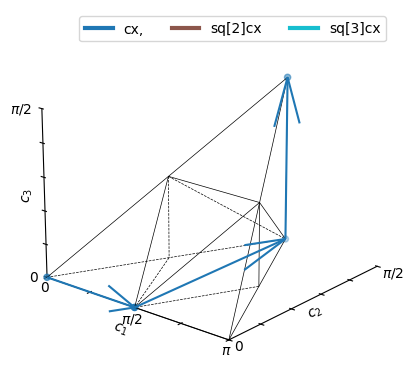

In [ ]:
target = SwapGate()
mono_result = decomposer._best_decomposition(target)
mono_result.render_path()

In [517]:
from monodromy.coordinates import unitary_to_monodromy_coordinate
from qiskit.circuit.library import iSwapGate, CZGate, CXGate, UnitaryGate
from hetero_isas.monodromy_lp.invariants import (
    mono_coordinates_to_CAN,
    recover_local_equivalence,
)
from qiskit import QuantumCircuit
from qutip import Qobj
from qiskit.quantum_info import Operator
from weylchamber import c1c2c3

In [518]:
mono_coords = unitary_to_monodromy_coordinate(CZGate())
can = mono_coordinates_to_CAN(*mono_coords)
Qobj(can)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 7.07106781e-01+6.16573867e-17j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j -6.16573867e-17+7.07106781e-01j]
 [ 0.00000000e+00+0.00000000e+00j  7.07106781e-01-6.16573867e-17j
   6.16573867e-17+7.07106781e-01j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  6.16573867e-17+7.07106781e-01j
   7.07106781e-01-6.16573867e-17j  0.00000000e+00+0.00000000e+00j]
 [-6.16573867e-17+7.07106781e-01j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  7.07106781e-01+6.16573867e-17j]]

In [519]:
mono_coords = unitary_to_monodromy_coordinate(CXGate())
can = mono_coordinates_to_CAN(*mono_coords)
Qobj(can)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 7.07106781e-01+6.16573867e-17j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j -6.16573867e-17+7.07106781e-01j]
 [ 0.00000000e+00+0.00000000e+00j  7.07106781e-01-6.16573867e-17j
   6.16573867e-17+7.07106781e-01j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  6.16573867e-17+7.07106781e-01j
   7.07106781e-01-6.16573867e-17j  0.00000000e+00+0.00000000e+00j]
 [-6.16573867e-17+7.07106781e-01j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  7.07106781e-01+6.16573867e-17j]]

In [520]:
k1, k2, k3, k4, p = recover_local_equivalence(CXGate(), can)

In [521]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import CXGate, CZGate, UnitaryGate
from qiskit.quantum_info import Operator, average_gate_fidelity
import numpy as np

target_gate = CXGate()
basis_gate = CZGate()
print(average_gate_fidelity(target_gate, basis_gate))

k1, k2, k3, k4, gphase = recover_local_equivalence(target_gate, basis_gate)
qc = QuantumCircuit(2, global_phase=gphase)
qc.append(UnitaryGate(k1), [0])
qc.append(UnitaryGate(k2), [1])
qc.append(basis_gate, [0, 1])
qc.append(UnitaryGate(k3), [0])
qc.append(UnitaryGate(k4), [1])
print(average_gate_fidelity(target_gate, Operator(qc)))

0.4
0.9999999999999998


In [522]:
Qobj(Operator(qc).data)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.00000000e+00 -1.01465364e-17  1.66533454e-16 -1.38777878e-16]
 [ 1.94289029e-16  1.11022302e-16 -1.01465364e-17  1.00000000e+00]
 [ 2.22044605e-16 -1.38777878e-16  1.00000000e+00 -1.01465364e-17]
 [-1.01465364e-17  1.00000000e+00  1.94289029e-16  2.77555756e-16]]

In [523]:
Qobj(target_gate)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]]

In [524]:
k_vec = recover_local_equivalence(CXGate(), CZGate())
global_phase = k_vec[-1]
global_phase

-1.5707963267948966

In [525]:
from weylchamber import g1g2g3, c1c2c3
from qiskit.circuit.library import CXGate
import numpy as np

c1c2c3(CXGate().to_matrix())

(np.float64(0.5), np.float64(0.0), np.float64(0.0))

In [526]:
cx = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
c1c2c3(cx)

(np.float64(0.5), np.float64(0.0), np.float64(0.0))

In [527]:
from hetero_isas.monodromy_lp.invariants import unitary_to_mono_coordinates

unitary_to_mono_coordinates(CXGate().to_matrix())

(np.float64(0.25), np.float64(0.25), np.float64(-0.25), np.float64(-0.25))

In [528]:
from monodromy.coordinates import unitary_to_monodromy_coordinate

unitary_to_monodromy_coordinate(CXGate())

[np.float64(0.25000000000000006),
 np.float64(0.25000000000000006),
 np.float64(-0.25),
 np.float64(-0.25)]

In [529]:
from hetero_isas.monodromy_lp.singleq_numerics import two_qubit_local_invariants
from hetero_isas.zz_parallel_drive.bgate import BGate
from qiskit.circuit.library import SwapGate


two_qubit_local_invariants(SwapGate().to_matrix())

Array([-1., -0., -3.], dtype=float64)

In [530]:
SwapGate().to_matrix()

array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j]])

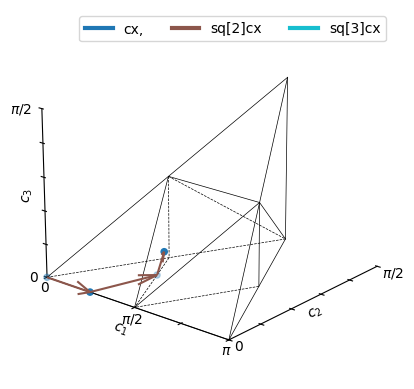

In [531]:
target = random_unitary(4).to_matrix()
decomp_result = decomposer._best_decomposition(target)
isa_sequence = decomp_result.isa_sequence
basis_gate_sequence = decomp_result.basis_gate_sequence
mono_points = decomp_result.mono_points
decomp_result.render_path()
traj_points = decomp_result.traj_points

In [532]:
from scipy.linalg import expm

SxSx = np.array([[0, 0, 0, 1], [0, 0, 1, 0], [0, 1, 0, 0], [1, 0, 0, 0]])
SySy = np.array([[+0, 0, 0, -1], [+0, 0, 1, 0], [+0, 1, 0, 0], [-1, 0, 0, 0]])
SzSz = np.array([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])


def canonical_gate(a, b, c):
    return expm(np.array(1j * (a * SxSx + b * SySy + c * SzSz)))


def canonicalize(target):
    target_decomp = TwoQubitWeylDecomposition(target, fidelity=1.0)
    canonical_target = canonical_gate(
        *np.array([-target_decomp.a, -target_decomp.b, -target_decomp.c])
    )
    return canonical_target


# b = QuantumCircuit(2)
# b.append(UnitaryGate(canonical_gate(np.pi / 4, np.pi / 8, 0)), [0, 1])
# b.draw("mpl");

In [533]:
rU = random_unitary(4).to_matrix()
rU = canonicalize(rU)
rU

array([[ 0.98289688+0.06426035j,  0.        +0.j        ,
         0.        +0.j        ,  0.01125908-0.17221373j],
       [ 0.        +0.j        ,  0.28170097-0.01841719j,
        -0.06258567-0.95728178j,  0.        +0.j        ],
       [ 0.        +0.j        , -0.06258567-0.95728178j,
         0.28170097-0.01841719j,  0.        +0.j        ],
       [ 0.01125908-0.17221373j,  0.        +0.j        ,
         0.        +0.j        ,  0.98289688+0.06426035j]])

In [619]:
Qobj(UnitaryGate(canonical_gate(np.pi / 4, np.pi / 8, 0)).to_matrix())

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.92387953+0.j         0.        +0.j         0.        +0.j
  0.        +0.38268343j]
 [0.        +0.j         0.38268343+0.j         0.        +0.92387953j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.92387953j 0.38268343+0.j
  0.        +0.j        ]
 [0.        +0.38268343j 0.        +0.j         0.        +0.j
  0.92387953+0.j        ]]

1.0000000000000004


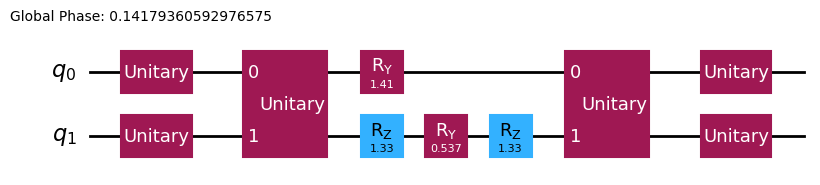

In [ ]:
from hetero_isas.monodromy_lp.invariants import recover_local_equivalence
from qiskit.synthesis.two_qubit import TwoQubitWeylDecomposition


def can_sandwich(target, exterior=True):
    target_decomp = TwoQubitWeylDecomposition(target, fidelity=1.0)
    tx, ty, tz = (2) * np.array([target_decomp.a, target_decomp.b, target_decomp.c])
    rb1 = 1 - 4 * np.sin(ty / 2) ** 2 * np.cos(tz / 2) ** 2
    b1 = np.arccos(rb1)
    rb2 = np.sqrt(
        np.cos(ty) * np.cos(tz) / (1 - 2 * np.sin(ty / 2) ** 2 * np.cos(tz / 2) ** 2)
    )
    b2 = np.arcsin(rb2)

    fix_phase = 1.0
    for _ in range(2):
        try:
            temp = QuantumCircuit(2)
            temp.append(UnitaryGate(canonical_gate(np.pi / 4, np.pi / 8, 0)), [0, 1])
            temp.ry(fix_phase * tx, 0)
            # temp.append(UnitaryGate(expm(tx * 1j / 2 * YGate().to_matrix())), [0])
            temp.rz(b2, 1)
            # temp.append(UnitaryGate(expm(b2 * 1j / 2 * ZGate().to_matrix())), [1])
            temp.ry(b1, 1)
            # temp.append(UnitaryGate(expm(b1 * 1j / 2 * YGate().to_matrix())), [1])
            temp.rz(b2, 1)
            # temp.append(UnitaryGate(expm(b2 * 1j / 2 * ZGate().to_matrix())), [1])
            temp.append(UnitaryGate(canonical_gate(np.pi / 4, np.pi / 8, 0)), [0, 1])
            # temp.draw()

            k_vec = recover_local_equivalence(target, Operator(temp))
            global_phase = k_vec[-1]
            k1, k2, k3, k4 = [UnitaryGate(k) for k in k_vec[:-1]]

            temp2 = QuantumCircuit(2, global_phase=global_phase)
            temp2.append(k1, [0])
            temp2.append(k2, [1])
            temp2.append(UnitaryGate(canonical_gate(np.pi / 4, np.pi / 8, 0)), [0, 1])
            temp2.ry(fix_phase * tx, 0)
            temp2.rz(b2, 1)
            temp2.ry(b1, 1)
            temp2.rz(b2, 1)
            temp2.append(UnitaryGate(canonical_gate(np.pi / 4, np.pi / 8, 0)), [0, 1])
            temp2.append(k3, [0])
            temp2.append(k4, [1])
            # temp2.draw("mpl");
        except:
            fix_phase = -1.0
            continue

    if not exterior:
        return temp
    return temp2


temp2 = can_sandwich(target)
print(average_gate_fidelity(Operator(target), Operator(temp2)))
temp2.draw("mpl")

(np.float64(0.49650875), np.float64(0.2499027), np.float64(0.07254888))

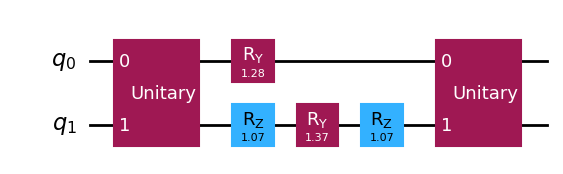

In [606]:
##### work backwards
rand_u = random_unitary(4).to_matrix()
temp = can_sandwich(rand_u, exterior=False)
temp.draw("mpl")

## also can choose random L, R can gates
L = canonical_gate(np.pi / 8, np.pi / 8, 0)
R = canonical_gate(np.pi / 8, np.pi / 4, 0)

T = L @ Operator(temp).data @ R
c1c2c3(T)

In [615]:
Operator(temp)

Operator([[ 0.21127422-0.27714209j, -0.15735455-0.35885233j,
           -0.76432327-0.15735455j,  0.26726898+0.21127422j],
          [ 0.15735455+0.35885233j, -0.21127422-0.81168005j,
            0.26726898+0.21127422j,  0.04661861-0.15735455j],
          [ 0.76432327+0.15735455j,  0.26726898+0.21127422j,
           -0.21127422+0.27714209j, -0.15735455-0.35885233j],
          [ 0.26726898+0.21127422j, -0.04661861+0.15735455j,
            0.15735455+0.35885233j,  0.21127422+0.81168005j]],
         input_dims=(2, 2), output_dims=(2, 2))


In [616]:
Operator(
    can_sandwich(np.matrix(L).getH() @ T @ np.matrix(R).getH(), exterior=False)
).data

array([[ 0.21127422-0.27714209j, -0.15735455-0.35885233j,
        -0.76432327-0.15735455j,  0.26726898+0.21127422j],
       [ 0.15735455+0.35885233j, -0.21127422-0.81168005j,
         0.26726898+0.21127422j,  0.04661861-0.15735455j],
       [ 0.76432327+0.15735455j,  0.26726898+0.21127422j,
        -0.21127422+0.27714209j, -0.15735455-0.35885233j],
       [ 0.26726898+0.21127422j, -0.04661861+0.15735455j,
         0.15735455+0.35885233j,  0.21127422+0.81168005j]])

In [583]:
Operator(temp).equiv(np.matrix(L).getH() @ T @ np.matrix(R).getH())

True

In [584]:
k1, k2, k3, k4 = (
    random_unitary(2).to_matrix(),
    random_unitary(2).to_matrix(),
    random_unitary(2).to_matrix(),
    random_unitary(2).to_matrix(),
)

k1k2 = np.kron(k1, k2)
k3k4 = np.kron(k3, k4)

Operator(k1k2 @ np.matrix(L).getH() @ T @ np.matrix(R).getH() @ k3k4).equiv(
    k1k2 @ Operator(temp).data @ k3k4
)

True

In [585]:
Td = k1k2 @ np.matrix(L).getH() @ T @ np.matrix(R).getH() @ k3k4
Operator(L @ np.matrix(k1k2).getH() @ Td @ np.matrix(k3k4).getH() @ R).equiv(T)

True

In [586]:
Operator(L @ np.matrix(k1k2).getH() @ Td @ np.matrix(k3k4).getH() @ R).equiv(
    L @ Operator(temp).data @ R
)

True

In [587]:
Operator(np.matrix(k1k2).getH() @ Td @ np.matrix(k3k4).getH()).equiv(
    Operator(temp).data
)

True

In [588]:
Operator(k1k2 @ Operator(temp).data @ k3k4).equiv(Td)

True

In [561]:
################

In [603]:
# define some new target
T_n = random_unitary(4).to_matrix()
left = np.matrix(L).getH() @ T_n @ np.matrix(R).getH()
cansd = can_sandwich(left, exterior=False)

In [604]:
Operator(cansd).equiv(left)

False

In [ ]:
#####

In [535]:
k1d = temp2[0].operation.adjoint()
k2d = temp2[1].operation.adjoint()
k3d = temp2[-2].operation.adjoint()
k4d = temp2[-1].operation.adjoint()
bd = temp2[2].operation.adjoint()

In [536]:
rtemp = QuantumCircuit(2)
rtemp.append(bd, [0, 1])
rtemp.append(k1d, [0])
rtemp.append(k2d, [1])
rtemp.append(UnitaryGate(target), [0, 1])
rtemp.append(k3d, [0])
rtemp.append(k4d, [1])
rtemp.append(bd, [0, 1])
c1c2c3(Operator(rtemp).data)

(np.float64(1.0), np.float64(0.0), np.float64(0.0))

In [537]:
uu = L @ Operator(rtemp).data @ R
c1c2c3(uu)

(np.float64(0.5), np.float64(0.11223873), np.float64(0.11223873))

In [538]:
c1c2c3(target)

(np.float64(0.44867805), np.float64(0.12185747), np.float64(0.10484881))

In [539]:
tt = np.matrix(L).getH() @ target @ np.matrix(R).getH()
c1c2c3(tt)

(np.float64(0.50535914), np.float64(0.2461816), np.float64(0.03535347))

(np.float64(0.45892513), np.float64(0.18266519), np.float64(0.0))

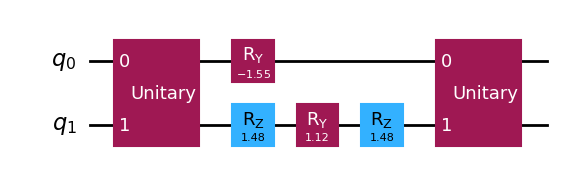

(np.float64(0.49845908), np.float64(0.15745067), np.float64(0.0))

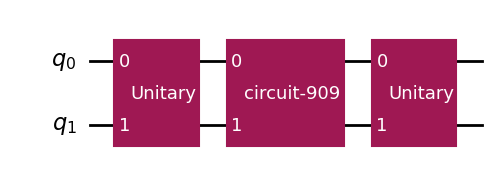

In [513]:
temp3 = QuantumCircuit(2)
temp3.append(UnitaryGate(L), [0, 1])
temp3.append(temp, [0, 1])
temp3.append(UnitaryGate(R), [0, 1])
temp3.draw("mpl")
c1c2c3(Operator(temp3).data)

In [433]:
from numpy.linalg import svd

U, S, Vh = np.linalg.svd(uu, full_matrices=True)

In [435]:
c1c2c3(U)

(np.float64(0.74911295), np.float64(0.09215039), np.float64(0.07129457))

In [441]:
c1c2c3(Vh @ L @ bd.to_matrix())

(np.float64(0.40266196), np.float64(0.16961107), np.float64(0.06675021))

In [431]:
from numpy.linalg import det

det(uu)

np.complex128(-0.9830183702120523-0.18350717649629328j)

In [405]:
MAGIC = np.matrix(
    [[1, 0, 0, 1j], [0, 1j, 1, 0], [0, 1j, -1, 0], [1, 0, 0, -1j]]
) / np.sqrt(2)

In [370]:
target

array([[ 0.35979674+0.03266588j, -0.00912636+0.65581248j,
        -0.1950791 +0.58879196j, -0.07833607-0.22008541j],
       [-0.03883372+0.10894781j,  0.0473285 +0.528262j  ,
         0.17084348-0.21211425j,  0.47481444+0.63694025j],
       [-0.68508738-0.14278593j,  0.31068915+0.30880995j,
        -0.47427164-0.10416452j, -0.28721202+0.01007717j],
       [-0.59625084-0.10418233j, -0.31030737+0.01854637j,
         0.36152223+0.41785891j,  0.40040071-0.26715392j]])

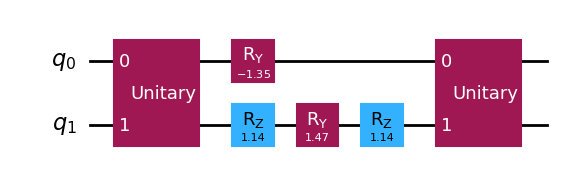

In [ ]:
temp.draw("mpl")

In [361]:
c1c2c3(target) == c1c2c3(Operator(temp))

True

In [362]:
c1c2c3(rU)

(np.float64(0.49609411), np.float64(0.39286793), np.float64(0.06208099))

In [363]:
c1c2c3(rU @ Operator(temp).data)

(np.float64(0.46570325), np.float64(0.25573344), np.float64(0.00530856))

In [364]:
c1c2c3(rU @ canonicalize(Operator(temp)))

(np.float64(0.2812286), np.float64(0.22202613), np.float64(0.07560201))

In [365]:
c1c2c3(rU @ Operator(temp2).data)

(np.float64(0.47953859), np.float64(0.20870179), np.float64(0.00739575))

In [366]:
c1c2c3(rU @ canonicalize(target))

(np.float64(0.2812286), np.float64(0.22202613), np.float64(0.07560201))

In [138]:
from hetero_isas.monodromy_lp.invariants import mono_coordinates_to_CAN

decomp_result.traj_points

[array([0., 0., 0.]),
 array([0.25, 0.  , 0.  ]),
 array([0.25645304, 0.24354696, 0.        ]),
 array([0.43614109, 0.23952928, 0.06629427])]

In [147]:
b = np.matrix(
    mono_coordinates_to_CAN(*decomp_result.isa_sequence[-1].definition)
).getH()

In [165]:
decomp_result.traj_points

[array([0., 0., 0.]),
 array([0.25, 0.  , 0.  ]),
 array([0.25645304, 0.24354696, 0.        ]),
 array([0.43614109, 0.23952928, 0.06629427])]

In [168]:
mono_coordinates_to_CAN(*decomp_result.mono_points[-1])

array([[ 0.94752684+0.09902873j,  0.        +0.j        ,
         0.        +0.j        , -0.0315947 +0.30230444j],
       [ 0.        +0.j        ,  0.48506027-0.05069503j,
         0.09074651+0.86828084j,  0.        +0.j        ],
       [ 0.        +0.j        ,  0.09074651+0.86828084j,
         0.48506027-0.05069503j,  0.        +0.j        ],
       [-0.0315947 +0.30230444j,  0.        +0.j        ,
         0.        +0.j        ,  0.94752684+0.09902873j]])

array([0.89073612, 0.29860801, 0.69900017])

In [219]:
import qutip

SxSx = qutip.Qobj(
    np.array(
        [[0, 0, 0, 1], [0, 0, 1, 0], [0, 1, 0, 0], [1, 0, 0, 0]],
        dtype=np.complex128,
    ),
    dims=[[2, 2], [2, 2]],
)


SySy = qutip.Qobj(
    np.array(
        [[+0, 0, 0, -1], [+0, 0, 1, 0], [+0, 1, 0, 0], [-1, 0, 0, 0]],
        dtype=np.complex128,
    ),
    dims=[[2, 2], [2, 2]],
)


SzSz = qutip.Qobj(
    np.array(
        [[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]],
        dtype=np.complex128,
    ),
    dims=[[2, 2], [2, 2]],
)

In [ ]:
def canonical_gate(c1, c2, c3):
    return (-np.pi * 0.5j * (c1 * SxSx + c2 * SySy + c3 * SzSz)).expm()


a, b, c = np.random.random(3)
d, e, f = np.random.random(3)

can_x = canonical_gate(a, b, c) @ canonical_gate(d, e, f)

In [228]:
c1c2c3(canonical_gate(a, b, c).full())

(np.float64(0.80432761), np.float64(0.09900179), np.float64(0.02090021))

In [229]:
c1c2c3(canonical_gate(d, e, f).full())

(np.float64(0.2169335), np.float64(0.20837478), np.float64(0.20636432))

In [227]:
np.array([a + d, b + e, c + f])

array([0.3053661 , 0.41260589, 0.81252543])

In [230]:
c1c2c3(can_x.full())

(np.float64(0.41260589), np.float64(0.3053661), np.float64(0.18747457))

In [246]:
decomp_result.traj_points

[array([0., 0., 0.]),
 array([0.25, 0.  , 0.  ]),
 array([0.25645304, 0.24354696, 0.        ]),
 array([0.43614109, 0.23952928, 0.06629427])]

In [250]:
# decomp_result.mono_points[1] @ [2] ?= 3
c1c2c3(
    canonical_gate(*decomp_result.traj_points[-2]).full()
    @ mono_coordinates_to_CAN(*decomp_result.isa_sequence[-1].definition)
)

(np.float64(0.24354696), np.float64(0.00645304), np.float64(0.0))

In [249]:
canonical_gate(*decomp_result.traj_points[-1]).full()

array([[ 0.94752684-0.09902873j,  0.        +0.j        ,
         0.        +0.j        , -0.0315947 -0.30230444j],
       [ 0.        +0.j        ,  0.48506027+0.05069503j,
         0.09074651-0.86828084j,  0.        +0.j        ],
       [ 0.        +0.j        ,  0.09074651-0.86828084j,
         0.48506027+0.05069503j,  0.        +0.j        ],
       [-0.0315947 -0.30230444j,  0.        +0.j        ,
         0.        +0.j        ,  0.94752684-0.09902873j]])

In [277]:
# from qiskit.synthesis.two_qubit.weyl import transform_to_magic_basis
from sympy.matrices import Matrix
from sympy import Symbol


def symbol_canonical_gate(a, b, c):
    a, b, c = Symbol(a), Symbol(b), Symbol(c)
    return Matrix(-1j * (a * SxSx.full() + b * SySy.full() + c * SzSz.full())).exp()


from qiskit.synthesis.two_qubit.weyl import _B_nonnormalized, _B_nonnormalized_dagger


def transform_to_magic_basis(U):
    return _B_nonnormalized @ U @ _B_nonnormalized_dagger


transform_to_magic_basis(symbol_canonical_gate("a", "b", "c"))

# def unsimplified_weyl_coordiates(U):
#     import scipy.linalg as la

#     pi2 = np.pi / 2
#     pi4 = np.pi / 4

#     U = U / la.det(U) ** (0.25)
#     Up = transform_to_magic_basis(U, reverse=True)
#     # We only need the eigenvalues of `M2 = Up.T @ Up` here, not the full diagonalization.
#     D = la.eigvals(Up.T @ Up)
#     d = -np.angle(D) / 2
#     d[3] = -d[0] - d[1] - d[2]
#     cs = np.mod((d[:3] + d[3]) / 2, 2 * np.pi)
#     return cs


# unsimplified_weyl_coordiates(target)

Matrix([
[ 0.25*exp(-I*a - I*b + I*c) + 0.25*exp(-I*a + I*b - I*c) + 0.25*exp(I*a - I*b - I*c) + 0.25*exp(I*a + I*b + I*c),  0.25*exp(-I*a - I*b + I*c) + 0.25*exp(-I*a + I*b - I*c) - 0.25*exp(I*a - I*b - I*c) - 0.25*exp(I*a + I*b + I*c),  0.25*exp(-I*a - I*b + I*c) - 0.25*exp(-I*a + I*b - I*c) + 0.25*exp(I*a - I*b - I*c) - 0.25*exp(I*a + I*b + I*c), -0.25*exp(-I*a - I*b + I*c) + 0.25*exp(-I*a + I*b - I*c) + 0.25*exp(I*a - I*b - I*c) - 0.25*exp(I*a + I*b + I*c)],
[ 0.25*exp(-I*a - I*b + I*c) + 0.25*exp(-I*a + I*b - I*c) - 0.25*exp(I*a - I*b - I*c) - 0.25*exp(I*a + I*b + I*c),  0.25*exp(-I*a - I*b + I*c) + 0.25*exp(-I*a + I*b - I*c) + 0.25*exp(I*a - I*b - I*c) + 0.25*exp(I*a + I*b + I*c),  0.25*exp(-I*a - I*b + I*c) - 0.25*exp(-I*a + I*b - I*c) - 0.25*exp(I*a - I*b - I*c) + 0.25*exp(I*a + I*b + I*c), -0.25*exp(-I*a - I*b + I*c) + 0.25*exp(-I*a + I*b - I*c) - 0.25*exp(I*a - I*b - I*c) + 0.25*exp(I*a + I*b + I*c)],
[ 0.25*exp(-I*a - I*b + I*c) - 0.25*exp(-I*a + I*b - I*c) + 0.25*exp(I*a - 

In [349]:
# Bell "Magic" basis
MAGIC = (
    1.0
    / np.sqrt(2)
    * np.array(
        [[1, 0, 0, 1j], [0, 1j, 1, 0], [0, 1j, -1, 0], [1, 0, 0, -1j]], dtype=complex
    )
)


def symbolic_invariants(U):
    Um = MAGIC.conj().T @ (U @ MAGIC)
    # Get determinate since +- one is allowed.
    # det_um = np.linalg.det(Um)
    det_um = Um.det()
    M = Um.T @ Um
    # trace(M)**2
    m_tr2 = M.trace()
    m_tr2 *= m_tr2

    # Table II of Ref. 1 or Eq. 28 of Ref. 2.
    G1 = m_tr2 / (16 * det_um)
    G2 = (m_tr2 - np.trace(M @ M)) / (4 * det_um)
    return G1, G2


U = symbol_canonical_gate("a", "b", "c")
symbolic_invariants(U)

(0.0441941738241592*I*(0.5*(-I*(-0.707106781186547*I*(0.5*exp(-I*a + I*b - I*c) - 0.5*exp(I*a - I*b - I*c)) + 0.707106781186547*I*(0.5*exp(-I*a + I*b - I*c) + 0.5*exp(I*a - I*b - I*c))) + I*(0.707106781186547*I*(0.5*exp(-I*a + I*b - I*c) - 0.5*exp(I*a - I*b - I*c)) - 0.707106781186547*I*(0.5*exp(-I*a + I*b - I*c) + 0.5*exp(I*a - I*b - I*c))))**2 - (I*(0.5*exp(-I*a - I*b + I*c) - 0.5*exp(I*a + I*b + I*c)) + I*(0.5*exp(-I*a - I*b + I*c) + 0.5*exp(I*a + I*b + I*c)))**2 + exp(-2*I*a + 2*I*b - 2*I*c) + exp(2*I*a + 2*I*b + 2*I*c))**2*exp(-I*a - I*b - I*c)*exp(I*a - I*b + I*c)/((-0.707106781186547*I*(-0.707106781186547*I*(0.5*exp(-I*a + I*b - I*c) - 0.5*exp(I*a - I*b - I*c)) + 0.707106781186547*I*(0.5*exp(-I*a + I*b - I*c) + 0.5*exp(I*a - I*b - I*c))) + 0.707106781186547*I*(0.707106781186547*I*(0.5*exp(-I*a + I*b - I*c) - 0.5*exp(I*a - I*b - I*c)) - 0.707106781186547*I*(0.5*exp(-I*a + I*b - I*c) + 0.5*exp(I*a - I*b - I*c))))*(0.707106781186547*I*(0.5*exp(-I*a - I*b + I*c) - 0.5*exp(I*a + I*b 

In [352]:
np.sqrt(2) / 2

np.float64(0.7071067811865476)

In [343]:
from sympy import arg

pi2 = np.pi / 2
pi4 = np.pi / 4


def symblolic_weyl(U):
    U = U / U.det() ** (0.25)
    Up = transform_to_magic_basis(U)
    D = (Up.T @ Up).eigenvals(multiple=True)
    d = np.array([-arg(Di) / 2 for Di in D])
    d[3] = -d[0] - d[1] - d[2]
    cs = d[:3] + d[3]
    return cs
    # cs = np.mod((d[:3] + d[3]) / 2, 2 * np.pi)

    # # Reorder the eigenvalues to get in the Weyl chamber
    # cstemp = np.mod(cs, pi2)
    # np.minimum(cstemp, pi2 - cstemp, cstemp)
    # order = np.argsort(cstemp)[[1, 2, 0]]
    # cs = cs[order]
    # d[:3] = d[order]

    # # Flip into Weyl chamber
    # if cs[0] > pi2:
    #     cs[0] -= 3 * pi2
    # if cs[1] > pi2:
    #     cs[1] -= 3 * pi2
    # conjs = 0
    # if cs[0] > pi4:
    #     cs[0] = pi2 - cs[0]
    #     conjs += 1
    # if cs[1] > pi4:
    #     cs[1] = pi2 - cs[1]
    #     conjs += 1
    # if cs[2] > pi2:
    #     cs[2] -= 3 * pi2
    # if conjs == 1:
    #     cs[2] = pi2 - cs[2]
    # if cs[2] > pi4:
    #     cs[2] -= pi2

    # return cs[[1, 0, 2]]


U = symbol_canonical_gate("a", "b", "c")
UU = symbol_canonical_gate("a", "b", "c") @ symbol_canonical_gate("e", "f", "g")
sympy_expr = symblolic_weyl(UU)
print(sympy_expr)
cs = [
    csi.subs([("a", np.pi / 4), ("b", np.pi), ("c", np.pi / 8)]) for csi in sympy_expr
]

cs = np.array([float(csi) for csi in cs])
cs = np.mod(cs, 2 * np.pi)

# Reorder the eigenvalues to get in the Weyl chamber
cstemp = np.mod(cs, pi2)
np.minimum(cstemp, pi2 - cstemp, cstemp)
order = np.argsort(cstemp)[[1, 2, 0]]
cs = cs[order]
d[:3] = d[order]

# Flip into Weyl chamber
if cs[0] > pi2:
    cs[0] -= 3 * pi2
if cs[1] > pi2:
    cs[1] -= 3 * pi2
conjs = 0
if cs[0] > pi4:
    cs[0] = pi2 - cs[0]
    conjs += 1
if cs[1] > pi4:
    cs[1] = pi2 - cs[1]
    conjs += 1
if cs[2] > pi2:
    cs[2] -= 3 * pi2
if conjs == 1:
    cs[2] = pi2 - cs[2]
if cs[2] > pi4:
    cs[2] -= pi2

cs[[1, 0, 2]]

[arg(exp(-2*I*a)*exp(2*I*b)*exp(-2*I*c)*exp(-2*I*e)*exp(2*I*f)*exp(-2*I*g))/2 + arg(exp(2*I*a)*exp(-2*I*b)*exp(-2*I*c)*exp(2*I*e)*exp(-2*I*f)*exp(-2*I*g))/2
 arg(exp(-2*I*a)*exp(-2*I*b)*exp(2*I*c)*exp(-2*I*e)*exp(-2*I*f)*exp(2*I*g))/2 + arg(exp(2*I*a)*exp(-2*I*b)*exp(-2*I*c)*exp(2*I*e)*exp(-2*I*f)*exp(-2*I*g))/2
 arg(exp(-2*I*a)*exp(-2*I*b)*exp(2*I*c)*exp(-2*I*e)*exp(-2*I*f)*exp(2*I*g))/2 + arg(exp(-2*I*a)*exp(2*I*b)*exp(-2*I*c)*exp(-2*I*e)*exp(2*I*f)*exp(-2*I*g))/2]


TypeError: Cannot convert expression to float

In [195]:
can_x

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.18948336-0.08099634j  0.        +0.j          0.        +0.j
   0.38461891+0.89977994j]
 [ 0.        +0.j          0.51790769+0.22138423j -0.32477859+0.75978912j
   0.        +0.j        ]
 [ 0.        +0.j         -0.32477859+0.75978912j  0.51790769+0.22138423j
   0.        +0.j        ]
 [ 0.38461891+0.89977994j  0.        +0.j          0.        +0.j
   0.18948336-0.08099634j]]

In [163]:
a = mono_coordinates_to_CAN(*decomp_result.mono_points[-1]) @ b
unitary_to_mono_coordinates(a)

(np.float64(0.30984122757793986),
 np.float64(0.004017678422481613),
 np.float64(-0.07031194974839655),
 np.float64(-0.24354695625202494))

In [157]:
decomposer._best_decomposition(target).mono_points

[(np.float64(0.0), np.float64(0.0), np.float64(0.0)),
 (np.float64(0.12500000000000014),
  np.float64(0.12500000000000014),
  np.float64(-0.12500000000000014)),
 (np.float64(0.2500000000000003),
  np.float64(0.006453043747974924),
  np.float64(-0.006453043747974924)),
 (np.float64(0.30468805025160317),
  np.float64(0.13145304374797506),
  np.float64(-0.06515877242206013))]

In [158]:
decomposer._best_decomposition(target).basis_gate_sequence[-1].to_matrix()

array([[1. +0.j , 0. +0.j , 0. +0.j , 0. +0.j ],
       [0. +0.j , 0.5+0.5j, 0. +0.j , 0.5-0.5j],
       [0. +0.j , 0. +0.j , 1. +0.j , 0. +0.j ],
       [0. +0.j , 0.5-0.5j, 0. +0.j , 0.5+0.5j]])

In [159]:
b = mono_coordinates_to_CAN(
    *unitary_to_mono_coordinates(
        decomposer._best_decomposition(target).basis_gate_sequence[-1]
    )
)

In [160]:
can_target = mono_coordinates_to_CAN(*unitary_to_mono_coordinates(target))

In [161]:
unitary_to_mono_coordinates(np.matrix(b).getH() @ can_target)

(np.float64(0.1796880502516031),
 np.float64(0.05984122757794006),
 np.float64(0.006453043747974916),
 np.float64(-0.24598232157751806))

In [162]:
g1g2g3(
    target
    @ np.matrix(
        decomposer._best_decomposition(target).basis_gate_sequence[-1].to_matrix()
    ).getH()
)

(np.float64(0.20490132), np.float64(0.03638582), np.float64(0.81400393))